## Data Observation

In [8]:
import pandas as pd
from pathlib import Path
import glob
import matplotlib.pyplot as plt

In [ ]:
TRAIN_FILE_NUMBERS = 11020
TRAIN_USER_NUMBERS = 60

TEST_FILE_NUMBERS = 6849
TEST_USER_NUMBERS = 40

In [ ]:
def get_train_user_file_csv(file_id, user_id = 0):
    assert 1 <= file_id and file_id <= 11020
    assert 0 <= user_id and user_id <= 60
    
    if (user_id != 0):
        return pd.read_csv(f'data/train/User_{user_id:03d}/{file_id:05d}.csv')
    
    pattern = f"data/train/User_*/{file_id:05d}.csv"
    matches = glob.glob(pattern)

    if len(matches) == 0:
        raise FileNotFoundError(f"No file found for file_id={file_id}")

    return pd.read_csv(matches[0])

def data_frame_to_figures(df):
    fig, axes = plt.subplots(3, 1, figsize=(15, 6), sharex=True)

    seconds = df['index']

    axes_map = {
        0: ('x axis', 'mean_x', 'std_x'),
        1: ('y axis', 'mean_y', 'std_y'),
        2: ('z axis', 'mean_z', 'std_z'),
    }

    for i, (label, mean_col, std_col) in axes_map.items():
        mean = df[mean_col]
        std = df[std_col]

        ax = axes[i]

        ax.plot(seconds, mean, color='blue', label='mean', lw = 0.5)

        ax.fill_between(
            seconds,
            mean - std,
            mean + std,
            color='blue',
            alpha=0.2,
            label='± std'
        )

        ax.set_title(label)
        ax.legend()

    fig.supylabel("acceleration [m/s²]")
    fig.supxlabel("time [seconds]")

    plt.tight_layout()
    plt.show()

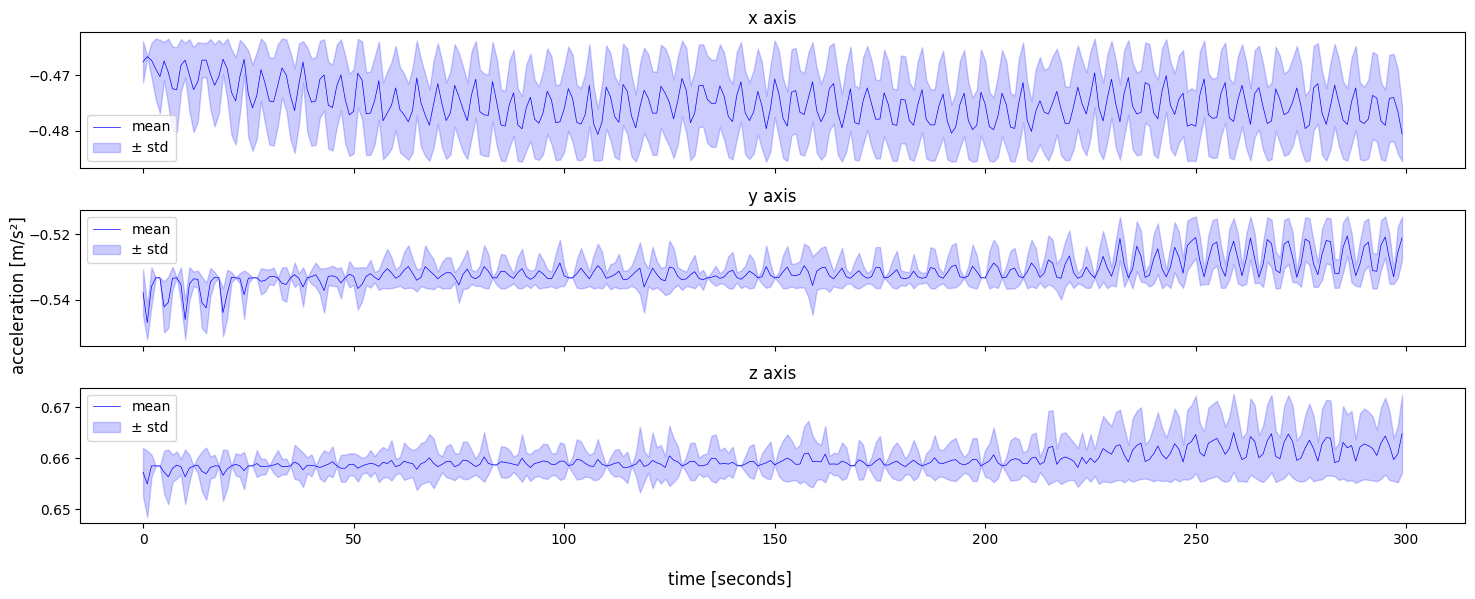

In [48]:
df = get_train_user_file_csv(1)
df.head()
data_frame_to_figures(df)